In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import itertools
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
sns.set_style('darkgrid')
from scipy import stats

In [7]:
def correlation_report(tickers, start_date, end_date):
  prices  = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)["Close"]
  prices  = prices.dropna()
  returns = np.log(prices / prices.shift(1)).dropna()

  corr_matrix = returns.corr()

  pairs = list(itertools.combinations(tickers, 2))
  rolling_corr = {}
  for t1, t2 in pairs:
      rolling_corr[f"{t1}_vs_{t2}"] = returns[t1].rolling(60).corr(returns[t2])

  rolling_corr_df = pd.DataFrame(rolling_corr)
  avg_corr = rolling_corr_df.mean(axis=1)

  scaler = StandardScaler()
  scaled = scaler.fit_transform(returns)
  pca = PCA()
  pca.fit(scaled)
  variance_explained = pca.explained_variance_ratio_
  cumulative_var = np.cumsum(variance_explained)
  n_components_80 = int(np.argmax(cumulative_var >= 0.80)) + 1

  return {
      "tickers": tickers,
      "start_date": start_date,
      "end_date": end_date,
      "returns": returns,
      "corr_matrix": corr_matrix,
      "rolling_corr": rolling_corr_df,
      "avg_corr": avg_corr,
      "variance_explained": variance_explained,
      "cumulative_var": cumulative_var,
      "n_components_80": n_components_80,
  }

In [10]:
TICKERS = ["SPY", "XLF", "GLD", "XLP", "BAC"]

calm     = correlation_report(TICKERS, "2004-01-01", "2006-12-31")
stressed = correlation_report(TICKERS, "2008-09-01", "2009-03-31")

print("CALM — Component 1 explains:   ", f"{calm['variance_explained'][0]:.1%}")
print("STRESSED — Component 1 explains:", f"{stressed['variance_explained'][0]:.1%}")
print("CALM — components to reach 80%:   ", calm['n_components_80'])
print("STRESSED — components to reach 80%:", stressed['n_components_80'])
print("\nCalm correlation matrix:")
print(calm['corr_matrix'].round(2))
print("\nStressed correlation matrix:")
print(stressed['corr_matrix'].round(2))

[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  5 of 5 completed

CALM — Component 1 explains:    63.3%
STRESSED — Component 1 explains: 65.6%
CALM — components to reach 80%:    2
STRESSED — components to reach 80%: 2

Calm correlation matrix:
Ticker   BAC   GLD   SPY   XLF   XLP
Ticker                              
BAC     1.00  0.08  0.66  0.79  0.54
GLD     0.08  1.00  0.09  0.05 -0.09
SPY     0.66  0.09  1.00  0.85  0.76
XLF     0.79  0.05  0.85  1.00  0.71
XLP     0.54 -0.09  0.76  0.71  1.00

Stressed correlation matrix:
Ticker   BAC   GLD   SPY   XLF   XLP
Ticker                              
BAC     1.00 -0.08  0.69  0.89  0.53
GLD    -0.08  1.00  0.04 -0.06 -0.06
SPY     0.69  0.04  1.00  0.85  0.85
XLF     0.89 -0.06  0.85  1.00  0.72
XLP     0.53 -0.06  0.85  0.72  1.00


In [9]:
acute = correlation_report(TICKERS, "2008-09-01", "2009-03-31")
print(acute['corr_matrix'].round(2))
print("Component 1:", f"{acute['variance_explained'][0]:.1%}")

[*********************100%***********************]  5 of 5 completed

Ticker   BAC   GLD   SPY   XLF   XLP
Ticker                              
BAC     1.00 -0.08  0.69  0.89  0.53
GLD    -0.08  1.00  0.04 -0.06 -0.06
SPY     0.69  0.04  1.00  0.85  0.85
XLF     0.89 -0.06  0.85  1.00  0.72
XLP     0.53 -0.06  0.85  0.72  1.00
Component 1: 65.6%


[*********************100%***********************]  5 of 5 completed


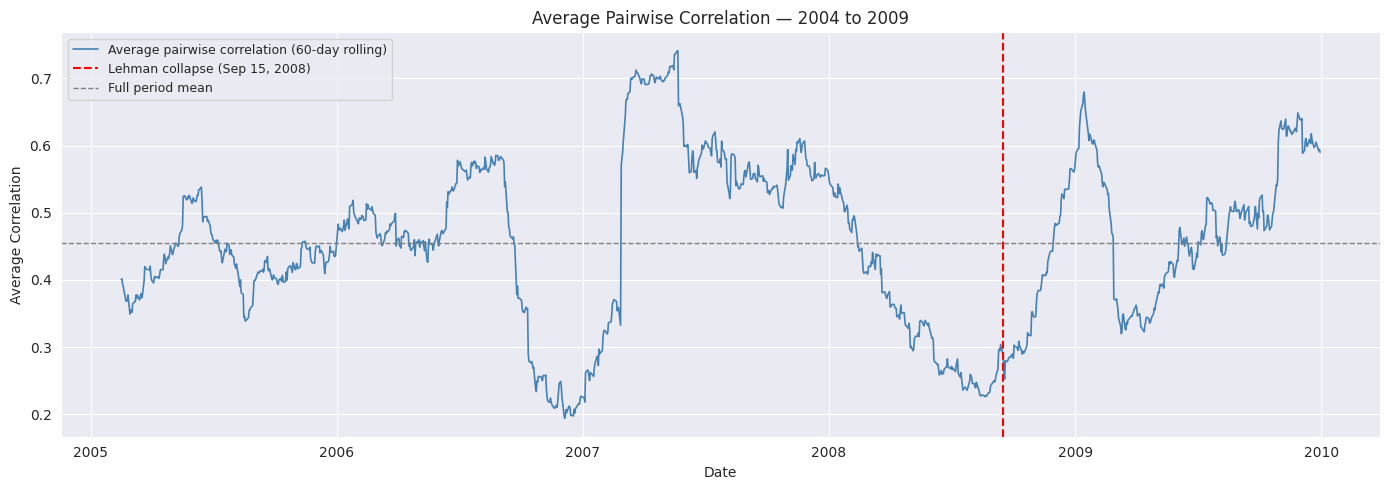

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))

full = correlation_report(TICKERS, "2004-01-01", "2009-12-31")

ax.plot(full['avg_corr'], color='steelblue', linewidth=1.2, label='Average pairwise correlation (60-day rolling)')
ax.axvline(pd.Timestamp("2008-09-15"), color='red', linestyle='--', linewidth=1.5, label='Lehman collapse (Sep 15, 2008)')
ax.axhline(full['avg_corr'].mean(), color='gray', linestyle='--', linewidth=1, label='Full period mean')
ax.set_title('Average Pairwise Correlation — 2004 to 2009')
ax.set_xlabel('Date')
ax.set_ylabel('Average Correlation')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [12]:
import seaborn as sns

def plot_correlation_report(calm, stressed):

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(
        f"Correlation Breakdown Analysis | "
        f"Calm: {calm['start_date']} → {calm['end_date']} | "
        f"Stressed: {stressed['start_date']} → {stressed['end_date']}",
        fontsize=13, fontweight='bold'
    )

    # --- Plot 1: Calm correlation heatmap ---
    sns.heatmap(calm['corr_matrix'], ax=axes[0, 0], annot=True, fmt='.2f',
                cmap='RdYlGn', vmin=-1, vmax=1, center=0,
                linewidths=0.5, annot_kws={"size": 10})
    axes[0, 0].set_title(f"Calm Period ({calm['start_date']} → {calm['end_date']})", fontsize=10)

    # --- Plot 2: Stressed correlation heatmap ---
    sns.heatmap(stressed['corr_matrix'], ax=axes[0, 1], annot=True, fmt='.2f',
                cmap='RdYlGn', vmin=-1, vmax=1, center=0,
                linewidths=0.5, annot_kws={"size": 10})
    axes[0, 1].set_title(f"Stressed Period ({stressed['start_date']} → {stressed['end_date']})", fontsize=10)

    # --- Plot 3: Rolling average correlation full period ---
    full = correlation_report(calm['tickers'], "2004-01-01", "2009-12-31")
    axes[1, 0].plot(full['avg_corr'], color='steelblue', linewidth=1.2,
                    label='Average pairwise correlation (60-day rolling)')
    axes[1, 0].axvline(pd.Timestamp("2008-09-15"), color='red', linestyle='--',
                        linewidth=1.5, label='Lehman collapse (Sep 15, 2008)')
    axes[1, 0].axvline(pd.Timestamp("2007-02-27"), color='orange', linestyle='--',
                        linewidth=1.5, label='First correlation spike (Feb 2007)')
    axes[1, 0].axhline(full['avg_corr'].mean(), color='gray', linestyle='--',
                        linewidth=1, label='Full period mean')
    axes[1, 0].set_title('Rolling Average Pairwise Correlation — 2004 to 2009', fontsize=10)
    axes[1, 0].set_xlabel('Date')
    axes[1, 0].set_ylabel('Average Correlation')
    axes[1, 0].legend(fontsize=8)

    # --- Plot 4: PCA variance explained ---
    n_components = len(calm['tickers'])
    x = np.arange(n_components)
    width = 0.35

    axes[1, 1].bar(x - width/2, calm['variance_explained'] * 100,
                   width, color='steelblue', alpha=0.8, label='Calm')
    axes[1, 1].bar(x + width/2, stressed['variance_explained'] * 100,
                   width, color='red', alpha=0.7, label='Stressed')
    axes[1, 1].set_title('PCA — Variance Explained by Component', fontsize=10)
    axes[1, 1].set_xlabel('Principal Component')
    axes[1, 1].set_ylabel('Variance Explained (%)')
    axes[1, 1].set_xticks(x)
    axes[1, 1].set_xticklabels([f'PC{i+1}' for i in range(n_components)])
    axes[1, 1].legend(fontsize=8)

    for i in range(n_components):
        axes[1, 1].text(i - width/2, calm['variance_explained'][i] * 100 + 0.5,
                        f"{calm['variance_explained'][i]:.1%}", ha='center', fontsize=7)
        axes[1, 1].text(i + width/2, stressed['variance_explained'][i] * 100 + 0.5,
                        f"{stressed['variance_explained'][i]:.1%}", ha='center', fontsize=7)

    plt.tight_layout()
    plt.show()

[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  5 of 5 completed


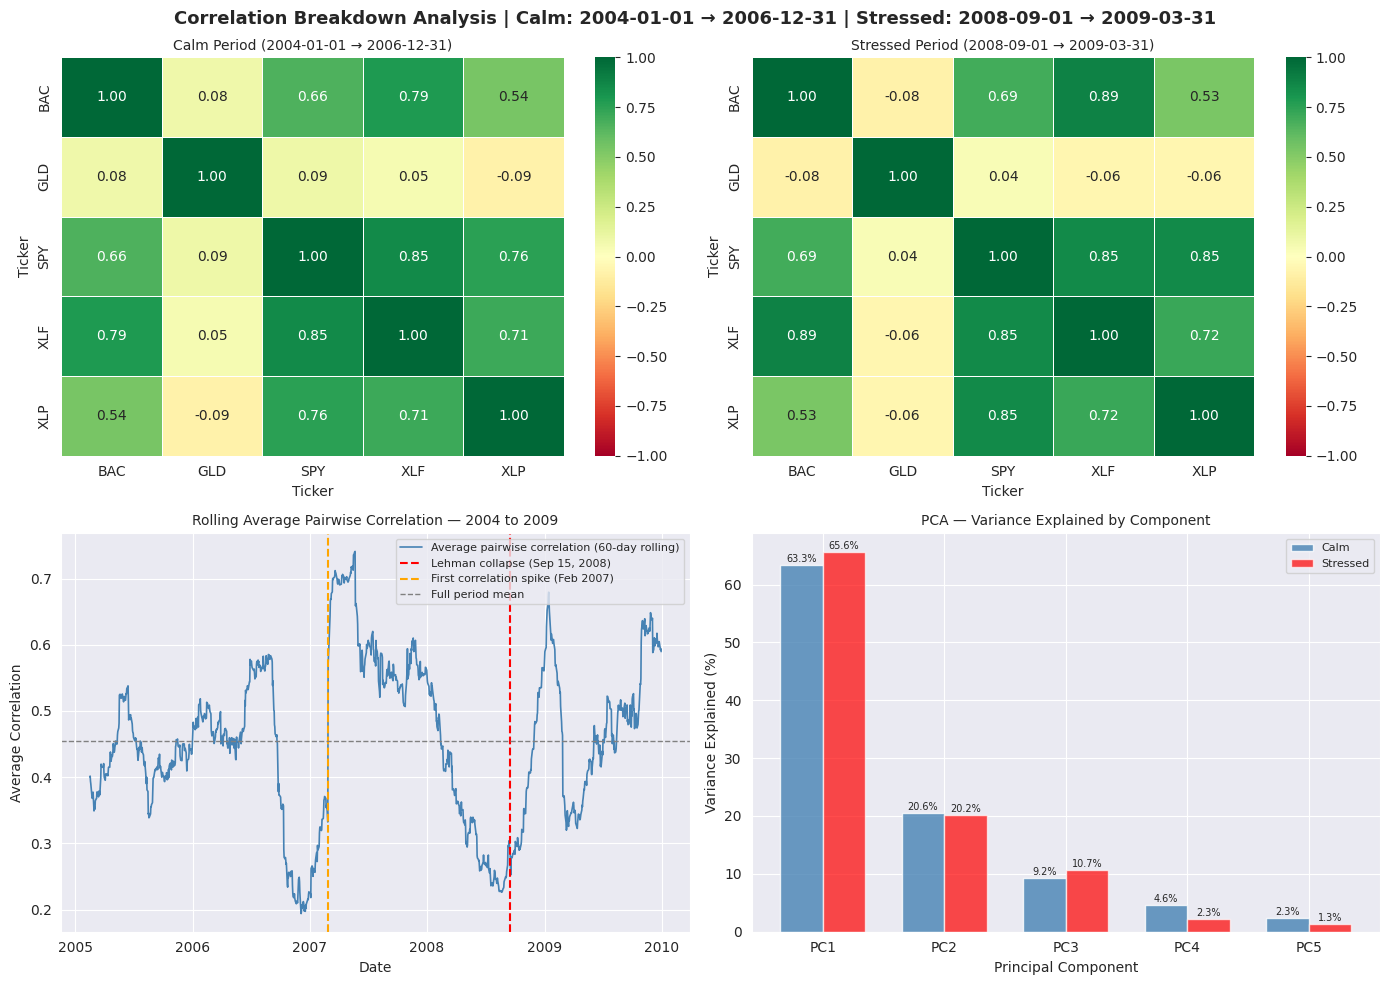

In [13]:
TICKERS = ["SPY", "XLF", "GLD", "XLP", "BAC"]

calm     = correlation_report(TICKERS, "2004-01-01", "2006-12-31")
stressed = correlation_report(TICKERS, "2008-09-01", "2009-03-31")

plot_correlation_report(calm, stressed)